In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [66]:
df = pd.read_csv(f'{os.getcwd()}/istherecorrelation.csv', delimiter=';', dtype={"Year": int, "WO [x1000]":str, "NL Beer consumption [x1000 hectoliter]": int})
df["WO [x1000]"] = df["WO [x1000]"].str.replace(',', '.').astype(float)
for column in df.columns:
    print(f"{column}: {df[column].dtype}")

Year: int64
WO [x1000]: float64
NL Beer consumption [x1000 hectoliter]: int64


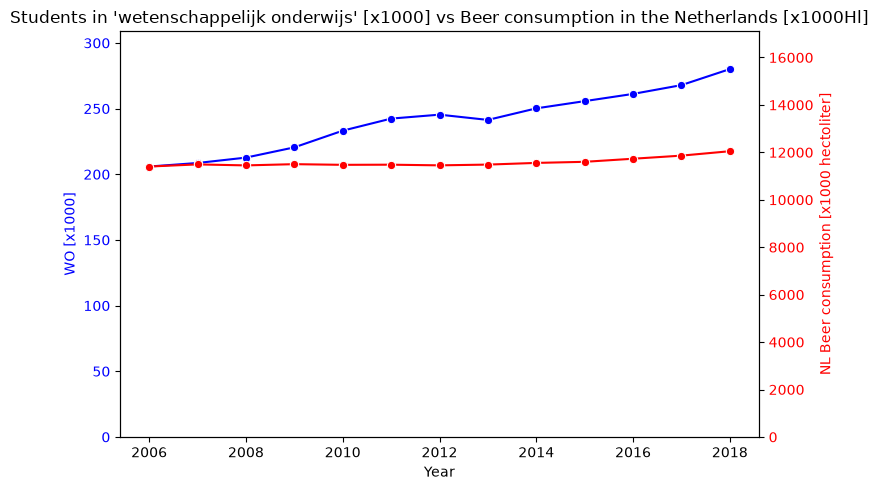

In [69]:
wo_col = "WO [x1000]"
beer_col = "NL Beer consumption [x1000 hectoliter]"

fig, ax1 = plt.subplots(figsize=(8, 5))

sns.lineplot(data=df, x="Year", y=wo_col, ax=ax1, color="blue", marker='o')
ax1.set_xlabel("Year")
ax1.set_ylabel("WO [x1000]", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()

sns.lineplot(data=df, x="Year", y=beer_col, ax=ax2, color="red", marker='o')
ax2.set_ylabel("NL Beer consumption [x1000 hectoliter]", color="red")
ax2.tick_params(axis="y", labelcolor="red")

ax2.grid(False)
ax1.set_ylim(0, 1.5 * df[wo_col].min())
ax2.set_ylim(0, 1.5 * df[beer_col].min())

plt.title("Students in 'wetenschappelijk onderwijs' [x1000] vs Beer consumption in the Netherlands [x1000Hl]")
plt.tight_layout()
plt.show()

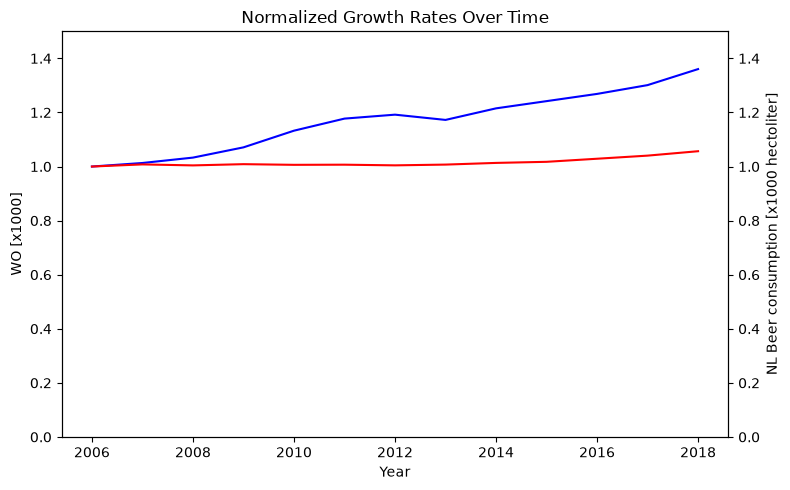

In [68]:
wo_col = "WO [x1000]"
beer_col = "NL Beer consumption [x1000 hectoliter]"
wo_norm = df[wo_col] / df[wo_col].min()
beer_norm = df[beer_col] / df[beer_col].min()

fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(data=df, x="Year", y=wo_norm, ax=ax, color="blue")
ax2 = ax.twinx()
sns.lineplot(data=df, x="Year", y=beer_norm, ax=ax2, color="red")

ax.set_ylim(0, 1.5)
ax2.set_ylim(0, 1.5)

plt.title("Normalized Growth Rates Over Time")
plt.tight_layout()
plt.show()